## Type classification

原始类别数: 15, 筛选后类别数: 12
原始样本数: 12495, 筛选后样本数: 12475

===== 交叉验证结果（平均 F1 分数 ± 标准差）=====
原始训练 + 量化测试：
b=1: 0.3112 ± 0.0222
b=2: 0.5590 ± 0.0263
b=3: 0.7012 ± 0.0535
b=4: 0.8781 ± 0.0230
b=5: 0.9073 ± 0.0066
b=6: 0.9248 ± 0.0091
b=7: 0.9501 ± 0.0053
b=8: 0.9484 ± 0.0050
b=9: 0.9569 ± 0.0043
b=10: 0.9581 ± 0.0040
b=11: 0.9597 ± 0.0035
b=12: 0.9597 ± 0.0042
b=13: 0.9597 ± 0.0040
b=14: 0.9597 ± 0.0034
b=15: 0.9596 ± 0.0034
b=16: 0.9597 ± 0.0034
b=17: 0.9601 ± 0.0041
b=18: 0.9602 ± 0.0043
b=19: 0.9600 ± 0.0043
b=20: 0.9599 ± 0.0043
b=21: 0.9601 ± 0.0041
b=22: 0.9599 ± 0.0042
b=23: 0.9601 ± 0.0041
b=24: 0.9602 ± 0.0040
b=25: 0.9602 ± 0.0040
b=26: 0.9602 ± 0.0041
b=27: 0.9602 ± 0.0041
b=28: 0.9602 ± 0.0041
b=29: 0.9602 ± 0.0041
b=30: 0.9602 ± 0.0041
b=31: 0.9602 ± 0.0041
b=32: 0.9602 ± 0.0041

量化训练 + 量化测试：
b=1: 0.7551 ± 0.0070
b=2: 0.9110 ± 0.0030
b=3: 0.9464 ± 0.0041
b=4: 0.9541 ± 0.0040
b=5: 0.9565 ± 0.0052
b=6: 0.9574 ± 0.0047
b=7: 0.9576 ± 0.0043
b=8: 0.9582 ± 0.0049
b=9: 0.9605 ± 0.0035
b=10

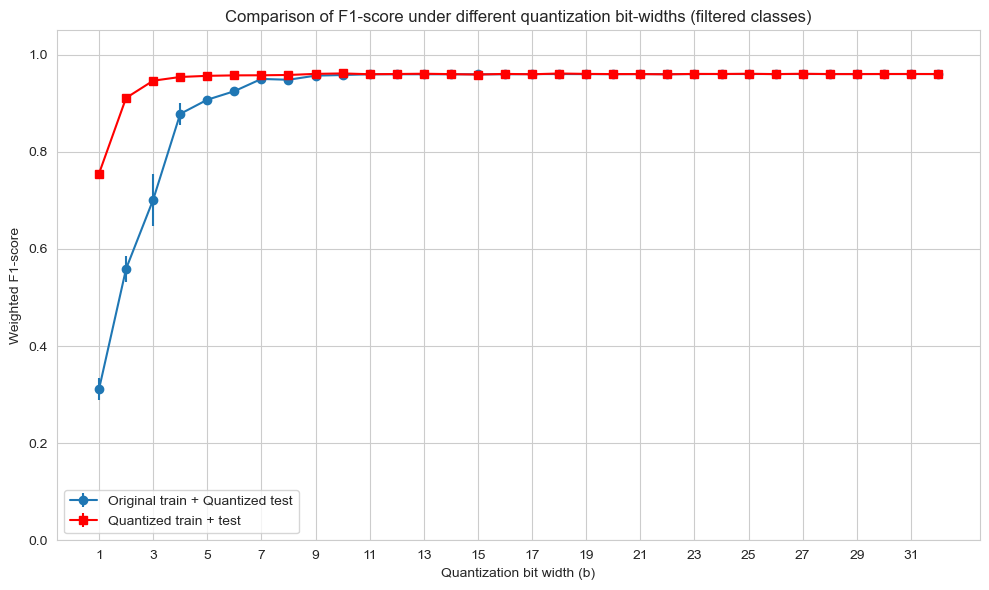

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"原始类别数: {len(data['Device Name'].unique())}, 筛选后类别数: {len(classes_to_keep)}")
    print(f"原始样本数: {len(data)}, 筛选后样本数: {len(filtered_data)}")
    return filtered_data

base_dir = "D:/ZBIOT-2025/Dataset"  # 改为相对路径，方便在不同环境运行
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
file_name = "Topology_A_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")

os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)

b_values = list(range(1, 33))
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path

if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"原始数据文件不存在: {original_file_path}")

original_data = pd.read_csv(file_paths["Original"])

original_data = filter_small_classes(original_data, min_samples=20)

categories = original_data["Device Type"].unique()

y_orig = pd.Categorical(original_data["Device Type"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name"])

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

f1_curve1 = {f"b{b}": [] for b in b_values}
f1_curve2 = {f"b{b}": [] for b in b_values}

fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):

    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]

    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]

    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}

    rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    rf_orig.fit(X_train_orig, y_train_orig)

    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            y_pred = rf_orig.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Type"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

            rf = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
            rf.fit(X_train, y_train)

            y_pred = rf.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1


f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

print("\n===== 交叉验证结果（平均 F1 分数 ± 标准差）=====")
print("原始训练 + 量化测试：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\n量化训练 + 量化测试：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Weighted F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (filtered classes)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

result_dir = os.path.join(base_dir, "Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Type.png"))
plt.show()


## Name classification

原始类别数: 15, 筛选后类别数: 12
原始样本数: 12495, 筛选后样本数: 12475

===== 交叉验证结果（平均 F1 分数 ± 标准差）=====
原始训练 + 量化测试：
b=1: 0.2800 ± 0.0044
b=2: 0.4109 ± 0.0213
b=3: 0.5884 ± 0.0139
b=4: 0.6902 ± 0.0105
b=5: 0.7098 ± 0.0076
b=6: 0.7773 ± 0.0122
b=7: 0.8139 ± 0.0053
b=8: 0.8250 ± 0.0052
b=9: 0.8436 ± 0.0061
b=10: 0.8496 ± 0.0045
b=11: 0.8506 ± 0.0022
b=12: 0.8518 ± 0.0036
b=13: 0.8515 ± 0.0034
b=14: 0.8536 ± 0.0035
b=15: 0.8520 ± 0.0042
b=16: 0.8532 ± 0.0043
b=17: 0.8540 ± 0.0042
b=18: 0.8539 ± 0.0033
b=19: 0.8533 ± 0.0036
b=20: 0.8538 ± 0.0039
b=21: 0.8538 ± 0.0042
b=22: 0.8535 ± 0.0041
b=23: 0.8537 ± 0.0041
b=24: 0.8536 ± 0.0040
b=25: 0.8537 ± 0.0043
b=26: 0.8538 ± 0.0043
b=27: 0.8539 ± 0.0043
b=28: 0.8537 ± 0.0041
b=29: 0.8537 ± 0.0041
b=30: 0.8536 ± 0.0041
b=31: 0.8537 ± 0.0041
b=32: 0.8537 ± 0.0041

量化训练 + 量化测试：
b=1: 0.5868 ± 0.0072
b=2: 0.7616 ± 0.0053
b=3: 0.8096 ± 0.0031
b=4: 0.8292 ± 0.0037
b=5: 0.8362 ± 0.0030
b=6: 0.8368 ± 0.0047
b=7: 0.8414 ± 0.0062
b=8: 0.8436 ± 0.0052
b=9: 0.8511 ± 0.0082
b=10

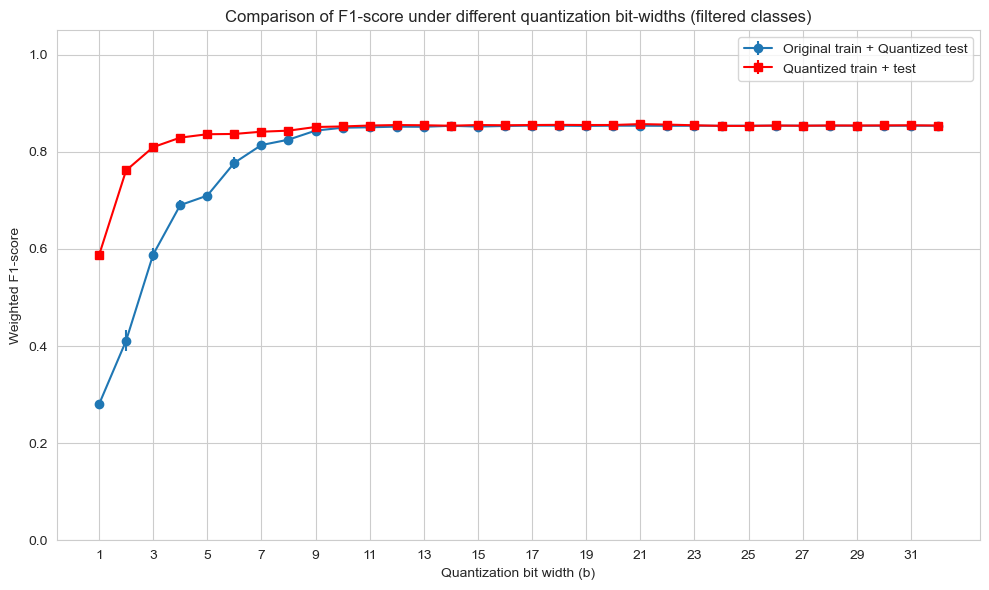

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"原始类别数: {len(data['Device Name'].unique())}, 筛选后类别数: {len(classes_to_keep)}")
    print(f"原始样本数: {len(data)}, 筛选后样本数: {len(filtered_data)}")
    return filtered_data

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")
file_name = "Topology_A_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")

os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)

b_values = list(range(1, 33))
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path

if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"原始数据文件不存在: {original_file_path}")

original_data = pd.read_csv(file_paths["Original"])

original_data = filter_small_classes(original_data, min_samples=20)

categories = original_data["Device Name"].unique()

y_orig = pd.Categorical(original_data["Device Name"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name"])

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

f1_curve1 = {f"b{b}": [] for b in b_values}
f1_curve2 = {f"b{b}": [] for b in b_values}

fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):
    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]

    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]

    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}

    rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    rf_orig.fit(X_train_orig, y_train_orig)

    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Name"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name"], categories=categories).codes

            y_pred = rf_orig.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Name"].isin(categories)].copy()

        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Name"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

            rf = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
            rf.fit(X_train, y_train)

            y_pred = rf.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1

f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

print("\n===== 交叉验证结果（平均 F1 分数 ± 标准差）=====")
print("原始训练 + 量化测试：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\n量化训练 + 量化测试：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Weighted F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (filtered classes)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

result_dir = os.path.join(base_dir, "Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Name.png"))
plt.show()
